In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("weather_forecast_data.csv")

In [4]:
print(df.info())
print(df.shape)
print(df.head())
print(df.tail())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
None
(2500, 6)
   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain
      Temperature   Humidity  Wind_Speed  Cloud_Cov

In [5]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()
df['Rain']=LE.fit_transform(df['Rain'])
print(df)


      Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure  Rain
0       23.720338  89.592641    7.335604    50.501694  1032.378759     1
1       27.879734  46.489704    5.952484     4.990053   992.614190     0
2       25.069084  83.072843    1.371992    14.855784  1007.231620     0
3       23.622080  74.367758    7.050551    67.255282   982.632013     1
4       20.591370  96.858822    4.643921    47.676444   980.825142     0
...           ...        ...         ...          ...          ...   ...
2495    21.791602  45.270902   11.807192    55.044682  1017.686181     0
2496    27.558479  46.481744   10.884915    39.715133  1008.590961     0
2497    28.108274  43.817178    2.897128    75.842952   999.119187     0
2498    14.789275  57.908105    2.374717     2.378743  1046.501875     0
2499    26.554356  97.101517   18.563084    81.357508  1001.729176     0

[2500 rows x 6 columns]


In [6]:
a=df.groupby('Temperature')['Rain'].mean()
print(a)
b=df.groupby('Humidity')['Rain'].mean()
print(b)
c=df.groupby('Wind_Speed')['Rain'].mean()
print(c)
d=df.groupby('Pressure')['Rain'].mean()
print(d)
e=df.groupby('Cloud_Cover')['Rain'].mean()
print(e)

Temperature
10.001842    0.0
10.009184    0.0
10.013649    0.0
10.016605    1.0
10.022582    1.0
            ... 
34.958872    0.0
34.963164    0.0
34.971175    0.0
34.981950    0.0
34.995214    0.0
Name: Rain, Length: 2500, dtype: float64
Humidity
30.005071    0.0
30.121648    0.0
30.127365    0.0
30.137290    0.0
30.137350    0.0
            ... 
99.814758    0.0
99.850059    1.0
99.995180    1.0
99.996428    0.0
99.997481    0.0
Name: Rain, Length: 2500, dtype: float64
Wind_Speed
0.009819     0.0
0.011392     0.0
0.017019     0.0
0.022441     0.0
0.027388     0.0
            ... 
19.956267    0.0
19.959636    0.0
19.966601    0.0
19.989565    1.0
19.999132    0.0
Name: Rain, Length: 2500, dtype: float64
Pressure
980.014486     0.0
980.023860     0.0
980.077778     0.0
980.108934     1.0
980.201216     0.0
              ... 
1049.867602    0.0
1049.907858    1.0
1049.911213    0.0
1049.939987    0.0
1049.985593    0.0
Name: Rain, Length: 2500, dtype: float64
Cloud_Cover
0.015038     

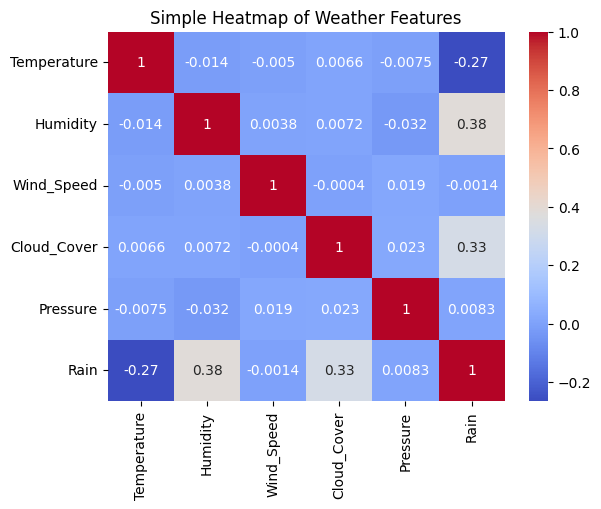

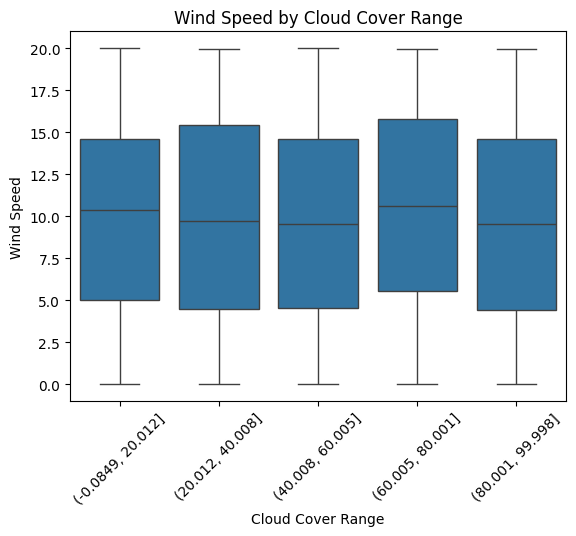

In [7]:
corr = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Simple Heatmap of Weather Features')
plt.show()


# Step 1: Bin the continuous 'Cloud_Cover' into 5 ranges
df['Cloud_Cover_Binned'] = pd.cut(df['Cloud_Cover'], bins=5)

# Step 2: Use the binned variable on the x-axis
sns.boxplot(x='Cloud_Cover_Binned', y='Wind_Speed', data=df)

# Step 3: Improve visualization
plt.xlabel('Cloud Cover Range')
plt.ylabel('Wind Speed')
plt.title('Wind Speed by Cloud Cover Range')
plt.xticks(rotation=45)
plt.show()


In [8]:
duplicate_rows=df[df.duplicated()]
print("duplicated rows",duplicate_rows.shape[0])

duplicated rows 0


In [9]:
print(df['Cloud_Cover'].max())
print(df['Cloud_Cover'].min())
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
df['Cloud_Cover']=ms.fit_transform(df[['Cloud_Cover']])
print(df)
print(df['Wind_Speed'].max())
print(df['Wind_Speed'].min())
df['Wind_Speed']=ms.fit_transform(df[['Wind_Speed']])
print(df)




99.99779517807228
0.0150381080855521
      Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure  Rain  \
0       23.720338  89.592641    7.335604     0.504954  1032.378759     1   
1       27.879734  46.489704    5.952484     0.049759   992.614190     0   
2       25.069084  83.072843    1.371992     0.148433  1007.231620     0   
3       23.622080  74.367758    7.050551     0.672518   982.632013     1   
4       20.591370  96.858822    4.643921     0.476696   980.825142     0   
...           ...        ...         ...          ...          ...   ...   
2495    21.791602  45.270902   11.807192     0.550391  1017.686181     0   
2496    27.558479  46.481744   10.884915     0.397069  1008.590961     0   
2497    28.108274  43.817178    2.897128     0.758410   999.119187     0   
2498    14.789275  57.908105    2.374717     0.023641  1046.501875     0   
2499    26.554356  97.101517   18.563084     0.813565  1001.729176     0   

     Cloud_Cover_Binned  
0      (40.008, 60.005] 

[]

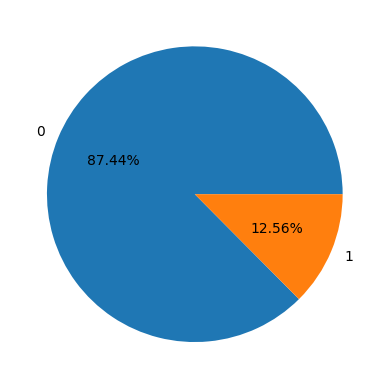

In [10]:
plt.pie(df['Rain'].value_counts(),labels=df['Rain'].value_counts().index,autopct='%1.2f%%')
plt.plot()

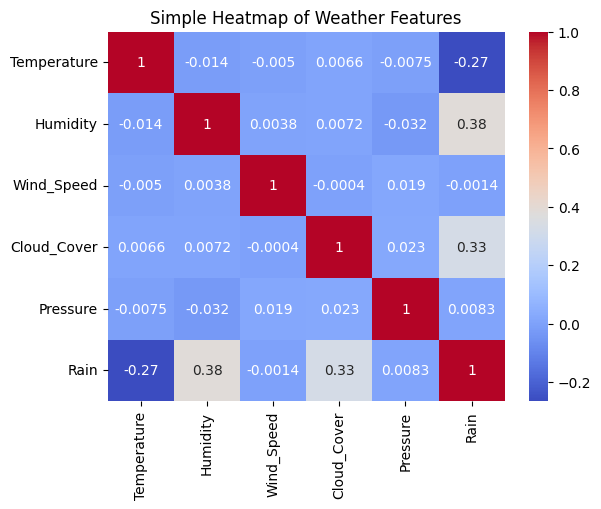

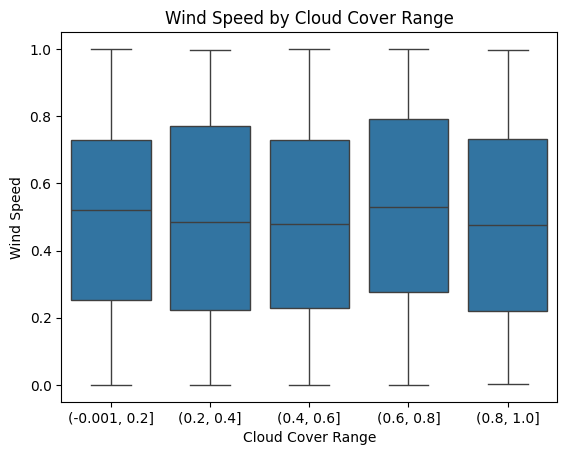

In [11]:
corr = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Simple Heatmap of Weather Features')
plt.show()



# Step 1: Bin the continuous 'Cloud_Cover' into 5 ranges
df['Cloud_Cover_Binned'] = pd.cut(df['Cloud_Cover'], bins=5)

# Step 2: Use the binned variable on the x-axis
sns.boxplot(x='Cloud_Cover_Binned', y='Wind_Speed', data=df)

# Step 3: Improve visualization
plt.xlabel('Cloud Cover Range')
plt.ylabel('Wind Speed')
plt.title('Wind Speed by Cloud Cover Range')
plt.show()


In [12]:
print(df)

      Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure  Rain  \
0       23.720338  89.592641    0.366485     0.504954  1032.378759     1   
1       27.879734  46.489704    0.297292     0.049759   992.614190     0   
2       25.069084  83.072843    0.068145     0.148433  1007.231620     0   
3       23.622080  74.367758    0.352225     0.672518   982.632013     1   
4       20.591370  96.858822    0.231829     0.476696   980.825142     0   
...           ...        ...         ...          ...          ...   ...   
2495    21.791602  45.270902    0.590184     0.550391  1017.686181     0   
2496    27.558479  46.481744    0.544045     0.397069  1008.590961     0   
2497    28.108274  43.817178    0.144443     0.758410   999.119187     0   
2498    14.789275  57.908105    0.118308     0.023641  1046.501875     0   
2499    26.554356  97.101517    0.928159     0.813565  1001.729176     0   

     Cloud_Cover_Binned  
0            (0.4, 0.6]  
1         (-0.001, 0.2]  
2        

In [13]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Rain', 'Cloud_Cover_Binned'])
y=df['Rain']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2000, 5)
(500, 5)
(2000,)
(500,)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("K-Nearest Neighbors (KNN) Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Support Vector Machine (SVM) Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("K-Nearest Neighbors (KNN) Confusion Matrix:",confusion_matrix(y_test, y_pred_knn))
print("Support Vector Machine (SVM) Confusion Matrix:",confusion_matrix(y_test, y_pred_svm))
print("Decision Tree Confusion Matrix:",confusion_matrix(y_test, y_pred_dt))
print("Logistic Regression Confusion Matrix:",confusion_matrix(y_test, y_pred_lr))
print("Random Forest Confusion Matrix:",confusion_matrix(y_test, y_pred_rf))

print("K-Nearest Neighbors (KNN) F1 Score:", f1_score(y_test, y_pred_knn))
print("Support Vector Machine (SVM) F1 Score:", f1_score(y_test, y_pred_svm))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred_lr))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

print("K-Nearest Neighbors (KNN) recall:",recall_score(y_test, y_pred_knn))
print("Support Vector Machine (SVM) recall:",recall_score(y_test, y_pred_svm))
print("Decision Tree recall:",recall_score(y_test, y_pred_dt))
print("Logistic Regression recall:",recall_score(y_test, y_pred_lr))
print("Random Forest recall:",recall_score(y_test, y_pred_rf))

print("K-Nearest Neighbors (KNN) precision:",precision_score(y_test, y_pred_knn))
print("Support Vector Machine (SVM) precision:",precision_score(y_test, y_pred_svm))
print("Decision Tree precision:",precision_score(y_test, y_pred_dt))
print("Logistic Regression precision:",precision_score(y_test, y_pred_lr))
print("Random Forest precision:",precision_score(y_test, y_pred_rf))



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


K-Nearest Neighbors (KNN) Accuracy: 0.854
Support Vector Machine (SVM) Accuracy: 0.886
Decision Tree Accuracy: 1.0
Logistic Regression Accuracy: 0.94
Random Forest Accuracy: 0.998
K-Nearest Neighbors (KNN) Confusion Matrix: [[405  38]
 [ 35  22]]
Support Vector Machine (SVM) Confusion Matrix: [[443   0]
 [ 57   0]]
Decision Tree Confusion Matrix: [[443   0]
 [  0  57]]
Logistic Regression Confusion Matrix: [[434   9]
 [ 21  36]]
Random Forest Confusion Matrix: [[443   0]
 [  1  56]]
K-Nearest Neighbors (KNN) F1 Score: 0.37606837606837606
Support Vector Machine (SVM) F1 Score: 0.0
Decision Tree F1 Score: 1.0
Logistic Regression F1 Score: 0.7058823529411765
Random Forest F1 Score: 0.9911504424778761
K-Nearest Neighbors (KNN) recall: 0.38596491228070173
Support Vector Machine (SVM) recall: 0.0
Decision Tree recall: 1.0
Logistic Regression recall: 0.631578947368421
Random Forest recall: 0.9824561403508771
K-Nearest Neighbors (KNN) precision: 0.36666666666666664
Support Vector Machine (SVM)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
import pickle
name='project.model'
fp=open(name,'wb')
df=pickle.dump(dt,fp)
fp.close()

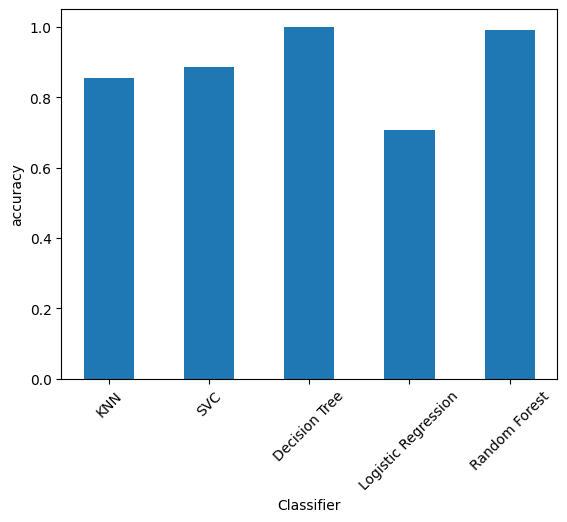

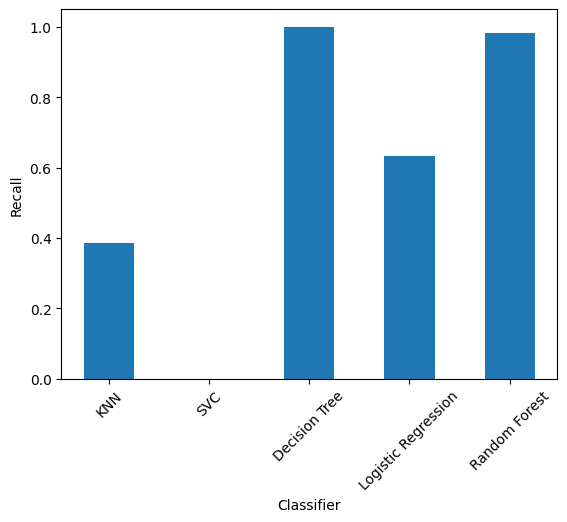

In [16]:
accuracy=[0.8554,0.886,1.0,0.7058,0.991]
recall=[0.3859,0.0,1.0,0.6315,0.9824]
names=['KNN','SVC','Decision Tree','Logistic Regression','Random Forest']
plt.bar(names,accuracy,width=0.5)
plt.ylabel('accuracy')
plt.xticks(rotation=45)
plt.xlabel('Classifier')
plt.show()
plt.bar(names,recall,width=0.5)
plt.ylabel('Recall')
plt.xticks(rotation=45)
plt.xlabel('Classifier')
plt.show()